In [12]:
import matplotlib.pyplot as plt
import pandas as pd

In [13]:


splits = {'BTC': 'data/BTC-00000-of-00001.parquet', 'TSLA': 'data/TSLA-00000-of-00001.parquet', 'MSFT': 'data/MSFT-00000-of-00001.parquet', 'ETH': 'data/ETH-00000-of-00001.parquet', 'BMRN': 'data/BMRN-00000-of-00001.parquet', 'MRNA': 'data/MRNA-00000-of-00001.parquet'}
df1 = pd.read_parquet("hf://datasets/TheFinAI/daily_news/" + splits["BTC"])
df2 = pd.read_parquet("hf://datasets/TheFinAI/daily_news/" + splits["TSLA"])
df3 = pd.read_parquet("hf://datasets/TheFinAI/daily_news/" + splits["MSFT"])
df4 = pd.read_parquet("hf://datasets/TheFinAI/daily_news/" + splits["ETH"])
df5 = pd.read_parquet("hf://datasets/TheFinAI/daily_news/" + splits["BMRN"])
df6 = pd.read_parquet("hf://datasets/TheFinAI/daily_news/" + splits["MRNA"])
df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)


In [14]:
df

,date,asset,prices,news,10k,10q,momentum,future_price_diff
0,2025-08-01,BTC,113343.120000,"[On August 1, 2025, the BTC news landscape pre...",[],[],bearish,-558.160000
1,2025-08-02,BTC,112784.960000,"[On August 2, 2025, the BTC news landscape pre...",[],[],bearish,1341.660000
2,2025-08-03,BTC,114126.620000,"[On August 3, 2025, the BTC news landscape pre...",[],[],bearish,1049.570000
3,2025-08-04,BTC,115176.190000,[The collection of BTC-focused articles from 2...,[],[],bullish,-984.700000
4,2025-08-05,BTC,114191.490000,[The collection of BTC-focused articles from A...,[],[],bullish,863.170000
...,...,...,...,...,...,...,...,...
1423,2026-03-22,MRNA,51.380001,[An OpenAI Web Search article summarizes Moder...,[],[],bearish,-0.100002
1424,2026-03-23,MRNA,51.279999,[The two articles published on 2026-03-23 pres...,[],[],bearish,0.060001
1425,2026-03-24,MRNA,51.340000,[The Moderna (MRNA) focus in these articles ce...,[],[],bearish,2.200001
1426,2026-03-25,MRNA,53.540001,"[The set of articles dated March 25, 2026 pres...",[],[],bullish,0.029999


In [15]:
# Build returns once, then tune tou separately per asset.
df['returns'] = df['future_price_diff'] / df['prices']

def pick_best_tou(asset_returns, quantile_grid=None):
    if quantile_grid is None:
        quantile_grid = [i / 100 for i in range(5, 46)]  # 5%..45%

    x = asset_returns.dropna()
    if x.empty:
        return None, None

    best_tou = None
    best_score = float('inf')
    best_props = None

    for q in quantile_grid:
        tou_candidate = x.abs().quantile(q)
        labels = x.apply(lambda r: 1 if r > tou_candidate else (-1 if r < -tou_candidate else 0))
        props = labels.value_counts(normalize=True).reindex([-1, 0, 1], fill_value=0)

        # Lower score means closer to balanced 1/3, 1/3, 1/3 labels.
        score = ((props - (1/3)) ** 2).sum()

        if score < best_score:
            best_score = score
            best_tou = tou_candidate
            best_props = props

    return best_tou, best_props

rows = []
for asset, g in df.groupby('asset'):
    best_tou, props = pick_best_tou(g['returns'])
    rows.append({
        'asset': asset,
        'best_tou': best_tou,
        'pct_-1': props.loc[-1] if props is not None else None,
        'pct_0': props.loc[0] if props is not None else None,
        'pct_1': props.loc[1] if props is not None else None,
    })

tou_by_asset = pd.DataFrame(rows).sort_values('asset').reset_index(drop=True)
tou_by_asset

,asset,best_tou,pct_-1,pct_0,pct_1
0,BMRN,0.000376,0.367089,0.329114,0.303797
1,BTC,0.007512,0.362869,0.320675,0.316456
2,ETH,0.008766,0.367089,0.329114,0.303797
3,MRNA,0.001348,0.312236,0.341772,0.345992
4,MSFT,0.000564,0.345992,0.341772,0.312236
5,TSLA,0.000951,0.308017,0.341772,0.350211


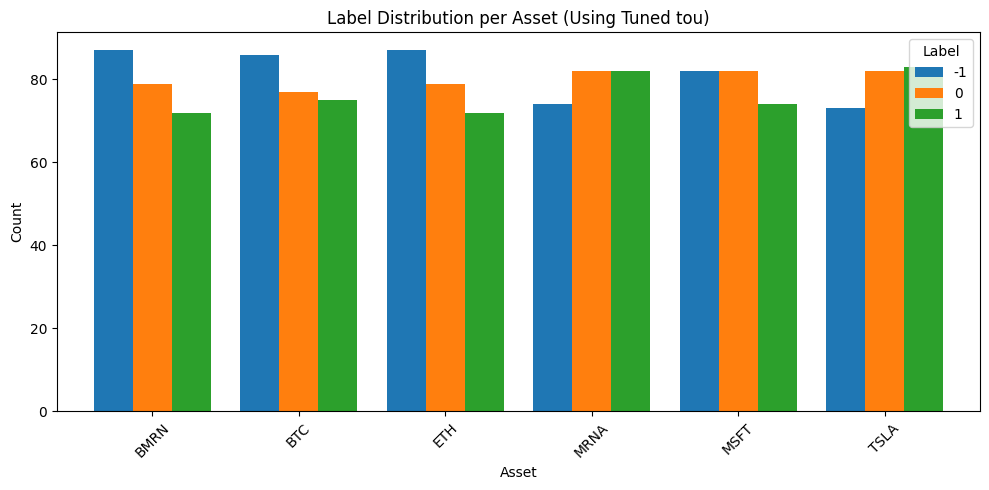

label,-1,0,1
asset,,,
BMRN,87,79,72
BTC,86,77,75
ETH,87,79,72
MRNA,74,82,82
MSFT,82,82,74
TSLA,73,82,83


In [16]:
# Map each asset to its tuned tou and create tuned labels.
tou_map = dict(zip(tou_by_asset['asset'], tou_by_asset['best_tou']))
df['tou_asset'] = df['asset'].map(tou_map)

df['label'] = df.apply(
    lambda row: 1 if row['returns'] > row['tou_asset'] else (-1 if row['returns'] < -row['tou_asset'] else 0),
    axis=1
)

label_dist_tuned = (
    df.groupby(['asset', 'label'])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=[-1, 0, 1], fill_value=0)
)

ax = label_dist_tuned.plot(kind='bar', figsize=(10, 5), width=0.8)
ax.set_title('Label Distribution per Asset (Using Tuned tou)')
ax.set_xlabel('Asset')
ax.set_ylabel('Count')
ax.legend(title='Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

label_dist_tuned

In [17]:
df

,date,asset,prices,news,10k,10q,momentum,future_price_diff,returns,tou_asset,label
0,2025-08-01,BTC,113343.120000,"[On August 1, 2025, the BTC news landscape pre...",[],[],bearish,-558.160000,-0.004925,0.007512,0
1,2025-08-02,BTC,112784.960000,"[On August 2, 2025, the BTC news landscape pre...",[],[],bearish,1341.660000,0.011896,0.007512,1
2,2025-08-03,BTC,114126.620000,"[On August 3, 2025, the BTC news landscape pre...",[],[],bearish,1049.570000,0.009197,0.007512,1
3,2025-08-04,BTC,115176.190000,[The collection of BTC-focused articles from 2...,[],[],bullish,-984.700000,-0.008550,0.007512,-1
4,2025-08-05,BTC,114191.490000,[The collection of BTC-focused articles from A...,[],[],bullish,863.170000,0.007559,0.007512,1
...,...,...,...,...,...,...,...,...,...,...,...
1423,2026-03-22,MRNA,51.380001,[An OpenAI Web Search article summarizes Moder...,[],[],bearish,-0.100002,-0.001946,0.001348,-1
1424,2026-03-23,MRNA,51.279999,[The two articles published on 2026-03-23 pres...,[],[],bearish,0.060001,0.001170,0.001348,0
1425,2026-03-24,MRNA,51.340000,[The Moderna (MRNA) focus in these articles ce...,[],[],bearish,2.200001,0.042852,0.001348,1
1426,2026-03-25,MRNA,53.540001,"[The set of articles dated March 25, 2026 pres...",[],[],bullish,0.029999,0.000560,0.001348,0


In [ ]:
df_returns_null = df[df['returns'].isna()].copy()
df = df[df['returns'].notna()].copy()

print('Rows with null returns:', len(df_returns_null))
print('Rows with non-null returns:', len(df))



Rows with null returns: 6
Rows with non-null returns: 1422


(            date asset        prices  \
 237   2026-03-26   BTC  68807.520000   
 475   2026-03-26  TSLA    372.109985   
 713   2026-03-26  MSFT    365.970001   
 951   2026-03-26   ETH   2060.140000   
 1189  2026-03-26  BMRN     55.549999   
 
                                                    news 10k 10q momentum  \
 237   [The batch of BTC-focused coverage on 2026-03-...  []  []  bearish   
 475   [Across the set of TSLA-focused coverage on 20...  []  []  bearish   
 713   [Across the MSFT-focused coverage dated 2026-0...  []  []  bearish   
 951   [The trio of Cointelegraph pieces from 2026-03...  []  []  bearish   
 1189  [Two articles dated 2026-03-26 address BioMari...  []  []  bullish   
 
       future_price_diff  returns  tou_asset  label  
 237                 NaN      NaN   0.007512      0  
 475                 NaN      NaN   0.000951      0  
 713                 NaN      NaN   0.000564      0  
 951                 NaN      NaN   0.008766      0  
 1189             

In [21]:
df_returns_null

,date,asset,prices,news,10k,10q,momentum,future_price_diff,returns,tou_asset,label
237,2026-03-26,BTC,68807.520000,[The batch of BTC-focused coverage on 2026-03-...,[],[],bearish,NaN,NaN,0.007512,0
475,2026-03-26,TSLA,372.109985,[Across the set of TSLA-focused coverage on 20...,[],[],bearish,NaN,NaN,0.000951,0
713,2026-03-26,MSFT,365.970001,[Across the MSFT-focused coverage dated 2026-0...,[],[],bearish,NaN,NaN,0.000564,0
951,2026-03-26,ETH,2060.140000,[The trio of Cointelegraph pieces from 2026-03...,[],[],bearish,NaN,NaN,0.008766,0
1189,2026-03-26,BMRN,55.549999,[Two articles dated 2026-03-26 address BioMari...,[],[],bullish,NaN,NaN,0.000376,0
1427,2026-03-26,MRNA,53.570000,"[The trio of March 26, 2026 articles presents ...",[],[],bullish,NaN,NaN,0.001348,0


In [22]:
df

,date,asset,prices,news,10k,10q,momentum,future_price_diff,returns,tou_asset,label
0,2025-08-01,BTC,113343.120000,"[On August 1, 2025, the BTC news landscape pre...",[],[],bearish,-558.160000,-0.004925,0.007512,0
1,2025-08-02,BTC,112784.960000,"[On August 2, 2025, the BTC news landscape pre...",[],[],bearish,1341.660000,0.011896,0.007512,1
2,2025-08-03,BTC,114126.620000,"[On August 3, 2025, the BTC news landscape pre...",[],[],bearish,1049.570000,0.009197,0.007512,1
3,2025-08-04,BTC,115176.190000,[The collection of BTC-focused articles from 2...,[],[],bullish,-984.700000,-0.008550,0.007512,-1
4,2025-08-05,BTC,114191.490000,[The collection of BTC-focused articles from A...,[],[],bullish,863.170000,0.007559,0.007512,1
...,...,...,...,...,...,...,...,...,...,...,...
1422,2026-03-21,MRNA,51.380001,[Moderna Inc. (MRNA) announced its fourth-quar...,[],[],bearish,0.000000,0.000000,0.001348,0
1423,2026-03-22,MRNA,51.380001,[An OpenAI Web Search article summarizes Moder...,[],[],bearish,-0.100002,-0.001946,0.001348,-1
1424,2026-03-23,MRNA,51.279999,[The two articles published on 2026-03-23 pres...,[],[],bearish,0.060001,0.001170,0.001348,0
1425,2026-03-24,MRNA,51.340000,[The Moderna (MRNA) focus in these articles ce...,[],[],bearish,2.200001,0.042852,0.001348,1
